In [1]:
# Use only 1 GPU if available
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"  # Disable progress bars

from chronos import BaseChronosPipeline, Chronos2Pipeline
from datetime import datetime
import torch
import os
from datetime import datetime
from ts_toolkit.utils.chronos_tune_input_generator import chronos_input_generator


torch.cuda.empty_cache()

## Does feature normalization doom exponential?
Experiment: Finetune Chronos on univariate exponential, test on exponential
Measurement: (Finetuned)/(Base) performance

### Data Generation ###

In [2]:
DISTRIBUTIONS = {
    "Deterministic Trends": ['constant', 'linear', 'exponential', 'staircase'],
    "Harmonic & Periodic": ['sine', 'sawtooth', 'square', 'triangle', 'noise_patch', 'fourier'],
    "Transient Dynamics": ['damped_sine', 'growing_sine', 'chirp'],
    "Autocorrelated Processes": ['ar', 'ma', 'arma', 'sarima', 'garch', 'pink_noise', 'fractional_brownian', 'markov_chain'], 
    "I.I.D. White Noise": ['normal', 'uniform', 'poisson', 'binary', 'student_t', 'lognormal', 'laplace', 'cauchy', 'skew_normal'],
    "Stochastic Drift/Shocks": ['random_walk', 'piecewise_constant', 'gbm', 'intermittent', 'impulse', 'logistic'], 
}

In [3]:
# List of level 1 dataset types, e.g., ["univariate_lagged", "multivariate_lagged"]. If None, all types are used.
dataset_level1 = ["univariate"] 
# List of level 2 dataset types, e.g., ["exponential", "noise_patch", "normal", "poisson", "random_walk"]. If None, all types are used.
dataset_level2 = ["exponential"]

data_path = "/home/nafiseh/GitHub/timeseries-research/data/simpletime/datasets_100k"
train_inputs, validation_inputs = chronos_input_generator(data_path, dataset_level1, dataset_level2, val_size=0.1)


univariate/exponential: 100000it [00:15, 6296.82it/s]
100%|██████████| 1/1 [00:15<00:00, 15.94s/it]


Prepared training inputs for 90000 training time series and 10000 validation time series.

Sample time series:
  Target shape: (256,)


### Fine-Tuning API

The `fit` method accepts:
- `inputs`: Time series for fine-tuning (same format as predict_quantiles)
- `prediction_length`: Forecast horizon for fine-tuning
- `validation_inputs`: Optional validation data (same format as inputs)
- `learning_rate`: Optimizer learning rate (default: 1e-5)
- `num_steps`: Number of training steps (default: 1000)
- `batch_size`: Batch size for training (default: 256)

Returns a new pipeline with the fine-tuned model.

In [4]:
output_dir = f"results/finetuned_models/chronos2/{datetime.now().strftime('%Y%m%d_%H%M%S')}"
# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

print(f"Fine-tuning Chronos-2 model. Output directory: {output_dir}")
# Fine-tune the model
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=48,
    num_steps=100_000,
    learning_rate=1e-4,
    batch_size=256,
    logging_steps=100,
    # finetune_mode="lora",
    output_dir=output_dir,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    validation_inputs=validation_inputs,
    eval_steps=100
) 

/tmp/ipykernel_1022756/786704418.py:7: FutureWarning: Fine-tuning support is experimental and may be changed in future versions.
  finetuned_pipeline = pipeline.fit(
/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss,Validation Loss
100,3.097900,2.586492
200,1.109300,0.339405
300,0.676100,0.675699
400,0.916700,0.542320
500,1.664700,0.746326
600,0.914200,0.391672
700,0.746600,0.337474
800,0.699500,0.388289
900,0.757400,0.650062
1000,1.021900,0.661601


KeyboardInterrupt: 

In [5]:
output_dir

'results/finetuned_models/chronos2/20260212_112618'

In [ ]:
break

Results written in 'results/finetuned_models/chronos2/20260212_112618'

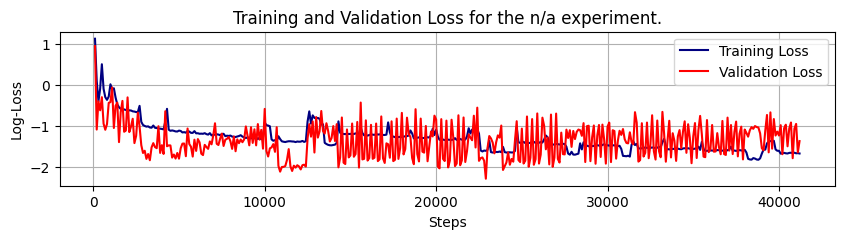

In [8]:
from ts_toolkit.pipeline.visualization import finetuning_curves

finetuning_curves(output_dir, figsize=(10, 2))

In [9]:
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config
from glob import glob
import os

ft_experiment = "Norm"
output_paths = {}

for multivariate in [True, False]:
    multivariate_str = "Multivariate" if multivariate else "Univariate"
    model_repo = f"results/finetuned_models/chronos2/20260212_112618"
    config_dict = {
        "experiment_name": f"Chronos2-FineTuned-{ft_experiment}-{multivariate_str}-SimpleTime",

        "paths": {
            "storage_path": "data/simpletime/datasets_100",
            "output_path": "results"
        },
        "forecaster": {
            "name": "MedianEnsemble",
            "max_length": 512,
            "models": [
                {
                    "name": "Chronos2",
                    "params": {
                        "repo_id": f"{model_repo}/finetuned-ckpt",
                        "batch_size": 64
                    },
                }
            ],
            "alias": f"Chronos2-FineTuned-{ft_experiment}-{multivariate_str}-SimpleTime"
        },
        "evaluation": {
            "to_univariate": not multivariate,
            "show_plot": False,
            "eval_substr": "dim0"
        }
    }
    
    config = load_config(config_dict=config_dict)
    # --- Set up the evaluation pipeline ---
    pipeline = TsPipeline(config)
    pipeline.run(skip_existing=True, num_plots=1)

    pipeline.get_results()
    output_paths[f"Chronos2 (Finetuned - {ft_experiment}) - {multivariate_str}"] = pipeline.output_path


Evaluating Datasets:   0%|          | 0/108 [00:00<?, ?it/s]

100it [00:00, 723.59it/s]
100it [00:00, 709.33it/s]
100it [00:00, 769.42it/s]
100it [00:00, 709.98it/s]
100it [00:00, 743.29it/s]
/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/gluonts/ev/aggregations.py:123: RuntimeWarning: invalid value encountered in divide
  return self.partial_result / self.n
❌ ERROR evaluating multivariate_lagged/garch (None): Input y contains infinity or a value too large for dtype('float64').
Skipping to the next dataset...
100it [00:00, 738.78it/s]
100it [00:00, 793.65it/s]
100it [00:00, 779.33it/s]
100it [00:00, 705.68it/s]
100it [00:00, 754.82it/s]
100it [00:00, 783.03it/s]
100it [00:00, 747.65it/s]
100it [00:00, 742.17it/s]
100it [00:00, 767.82it/s]
100it [00:00, 718.47it/s]
100it [00:00, 766.59it/s]
100it [00:00, 725.05it/s]
100it [00:00, 752.78it/s]
100it [00:00, 688.54it/s]
100it [00:00, 734.44it/s]
100it [00:00, 761.78it/s]
100it [00:00, 739.65it/s]
100it [00:00, 727.92it/s]
100it [00:00, 717.14it/s]
100it [00:00, 689.06it/s

Evaluating Datasets:   0%|          | 0/108 [00:00<?, ?it/s]

100it [00:00, 696.11it/s]
100it [00:00, 725.62it/s]
100it [00:00, 706.08it/s]
100it [00:00, 692.68it/s]
100it [00:00, 727.90it/s]
/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/gluonts/ev/aggregations.py:123: RuntimeWarning: invalid value encountered in divide
  return self.partial_result / self.n
❌ ERROR evaluating multivariate_lagged/garch (None): Input y contains infinity or a value too large for dtype('float64').
Skipping to the next dataset...
100it [00:00, 752.98it/s]
100it [00:00, 788.44it/s]
100it [00:00, 793.42it/s]
100it [00:00, 673.94it/s]
100it [00:00, 783.61it/s]
100it [00:00, 777.80it/s]
100it [00:00, 752.22it/s]
100it [00:00, 752.20it/s]
100it [00:00, 770.16it/s]
100it [00:00, 726.29it/s]
100it [00:00, 737.64it/s]
100it [00:00, 798.55it/s]
100it [00:00, 738.35it/s]
100it [00:00, 778.46it/s]
100it [00:00, 754.44it/s]
100it [00:00, 732.34it/s]
100it [00:00, 729.99it/s]
100it [00:00, 703.59it/s]
100it [00:00, 748.64it/s]
100it [00:00, 753.37it/s

In [10]:
output_paths

{'Chronos2 (Finetuned - Norm) - Multivariate': '/home/nafiseh/GitHub/timeseries-research/results/Chronos2-FineTuned-Norm-Multivariate-SimpleTime_20260212-132219',
 'Chronos2 (Finetuned - Norm) - Univariate': '/home/nafiseh/GitHub/timeseries-research/results/Chronos2-FineTuned-Norm-Univariate-SimpleTime_20260212-132752'}